# Support Vector Machines (SVM) — Wine Quality Demo

Support Vector Machines find the **maximum-margin hyperplane** that best separates classes. Key ideas:

**Core Concepts**
- **Support Vectors** — the training samples closest to the decision boundary; they alone determine the hyperplane.
- **Margin** — the distance between the hyperplane and the nearest support vectors. SVM maximises this margin.
- **Soft Margin (C)** — controls the trade-off between a wide margin and misclassifications. Large C = strict (low bias, high variance); small C = permissive (high bias, low variance).

**The Kernel Trick**

When data is not linearly separable, SVM maps it into a higher-dimensional space via a kernel function:
- **Linear**: `K(x, z) = x . z` — no transformation, works when classes are linearly separable.
- **RBF (Gaussian)**: `K(x, z) = exp(-gamma * ||x - z||^2)` — maps to infinite dimensions; `gamma` controls how far the influence of a single sample reaches.
- **Polynomial**: `K(x, z) = (gamma * x . z + r)^d` — captures polynomial relationships up to degree `d`.

**Important**: SVMs are **sensitive to feature scale**, so `StandardScaler` is essential.

---

In this notebook we will:
1. Load and explore the Wine Quality dataset
2. Preprocess (scale) features and prepare binary labels
3. Compare SVM kernels (linear, RBF, polynomial)
4. Visualise decision boundaries via PCA
5. Tune hyperparameters with GridSearchCV
6. Evaluate on multi-class quality scores

## 1. Setup & Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.decomposition import PCA

from data_loader import (
    load_wine_data,
    split_features_target,
    binarize_target,
    get_feature_names,
)
from model import (
    scale_features,
    train_svm,
    evaluate_model,
    predict,
    tune_hyperparameters,
)
from visualization import (
    plot_class_distribution,
    plot_feature_distributions,
    plot_correlation_heatmap,
    plot_confusion_matrix,
    plot_decision_boundary,
    plot_kernel_comparison,
)

sns.set_theme(style="whitegrid", palette="Set2")
RANDOM_STATE = 42

%matplotlib inline

## 2. Load & Explore Data

The Wine Quality dataset contains 11 physicochemical properties measured from wine samples and a quality score (target).

In [10]:
df = load_wine_data()
X, y = split_features_target(df)

print(f"Dataset shape: {df.shape}")
print(f"Features: {X.shape[1]}")
print(f"Samples : {X.shape[0]}")
df.head(10)

Dataset shape: (1699, 12)
Features: 11
Samples : 1699


,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5.0
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5.0
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6.0
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5.0
5,7.4,0.66,0.00,1.8,0.075,13.0,40.0,0.9978,3.51,0.56,9.4,5.0
6,7.9,0.60,0.06,1.6,0.069,15.0,59.0,0.9964,3.30,0.46,9.4,5.0
7,7.3,0.65,0.00,1.2,0.065,15.0,21.0,0.9946,3.39,0.47,10.0,7.0
8,7.8,0.58,0.02,2.0,0.073,9.0,18.0,0.9968,3.36,0.57,9.5,7.0
9,7.5,0.50,0.36,6.1,0.071,17.0,102.0,0.9978,3.35,0.80,10.5,5.0


In [3]:
df.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000,1699.000000
mean,8.329397,0.526786,0.271403,2.549096,0.087544,16.048253,46.897874,0.996747,3.311263,0.657206,10.421607,5.638028
std,1.726301,0.178695,0.194009,1.399910,0.046900,10.490591,32.733365,0.001887,0.154309,0.169189,1.066080,0.809308
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.094784,1.900000,0.070000,8.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.091000,22.000000,63.000000,0.997860,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [4]:
print("Missing values per column:")
print(df.isnull().sum())
print(f"\nTotal missing: {df.isnull().sum().sum()}")

Missing values per column:
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

Total missing: 0


## 3. Exploratory Data Analysis

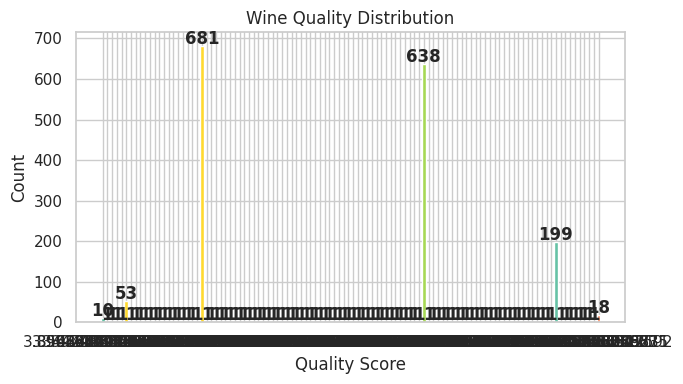

In [6]:
plot_class_distribution(y)
plt.show()

/workspaces/Pytorch-environment/ML_concepts/SVM/visualization.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x="quality", y=feat, ax=axes[i],
/workspaces/Pytorch-environment/ML_concepts/SVM/visualization.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x="quality", y=feat, ax=axes[i],
/workspaces/Pytorch-environment/ML_concepts/SVM/visualization.py:38: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=combined, x="quality", y=feat, ax=axes[i],
/workspaces/Pytorch-environment/ML_concepts/SVM/visualizat

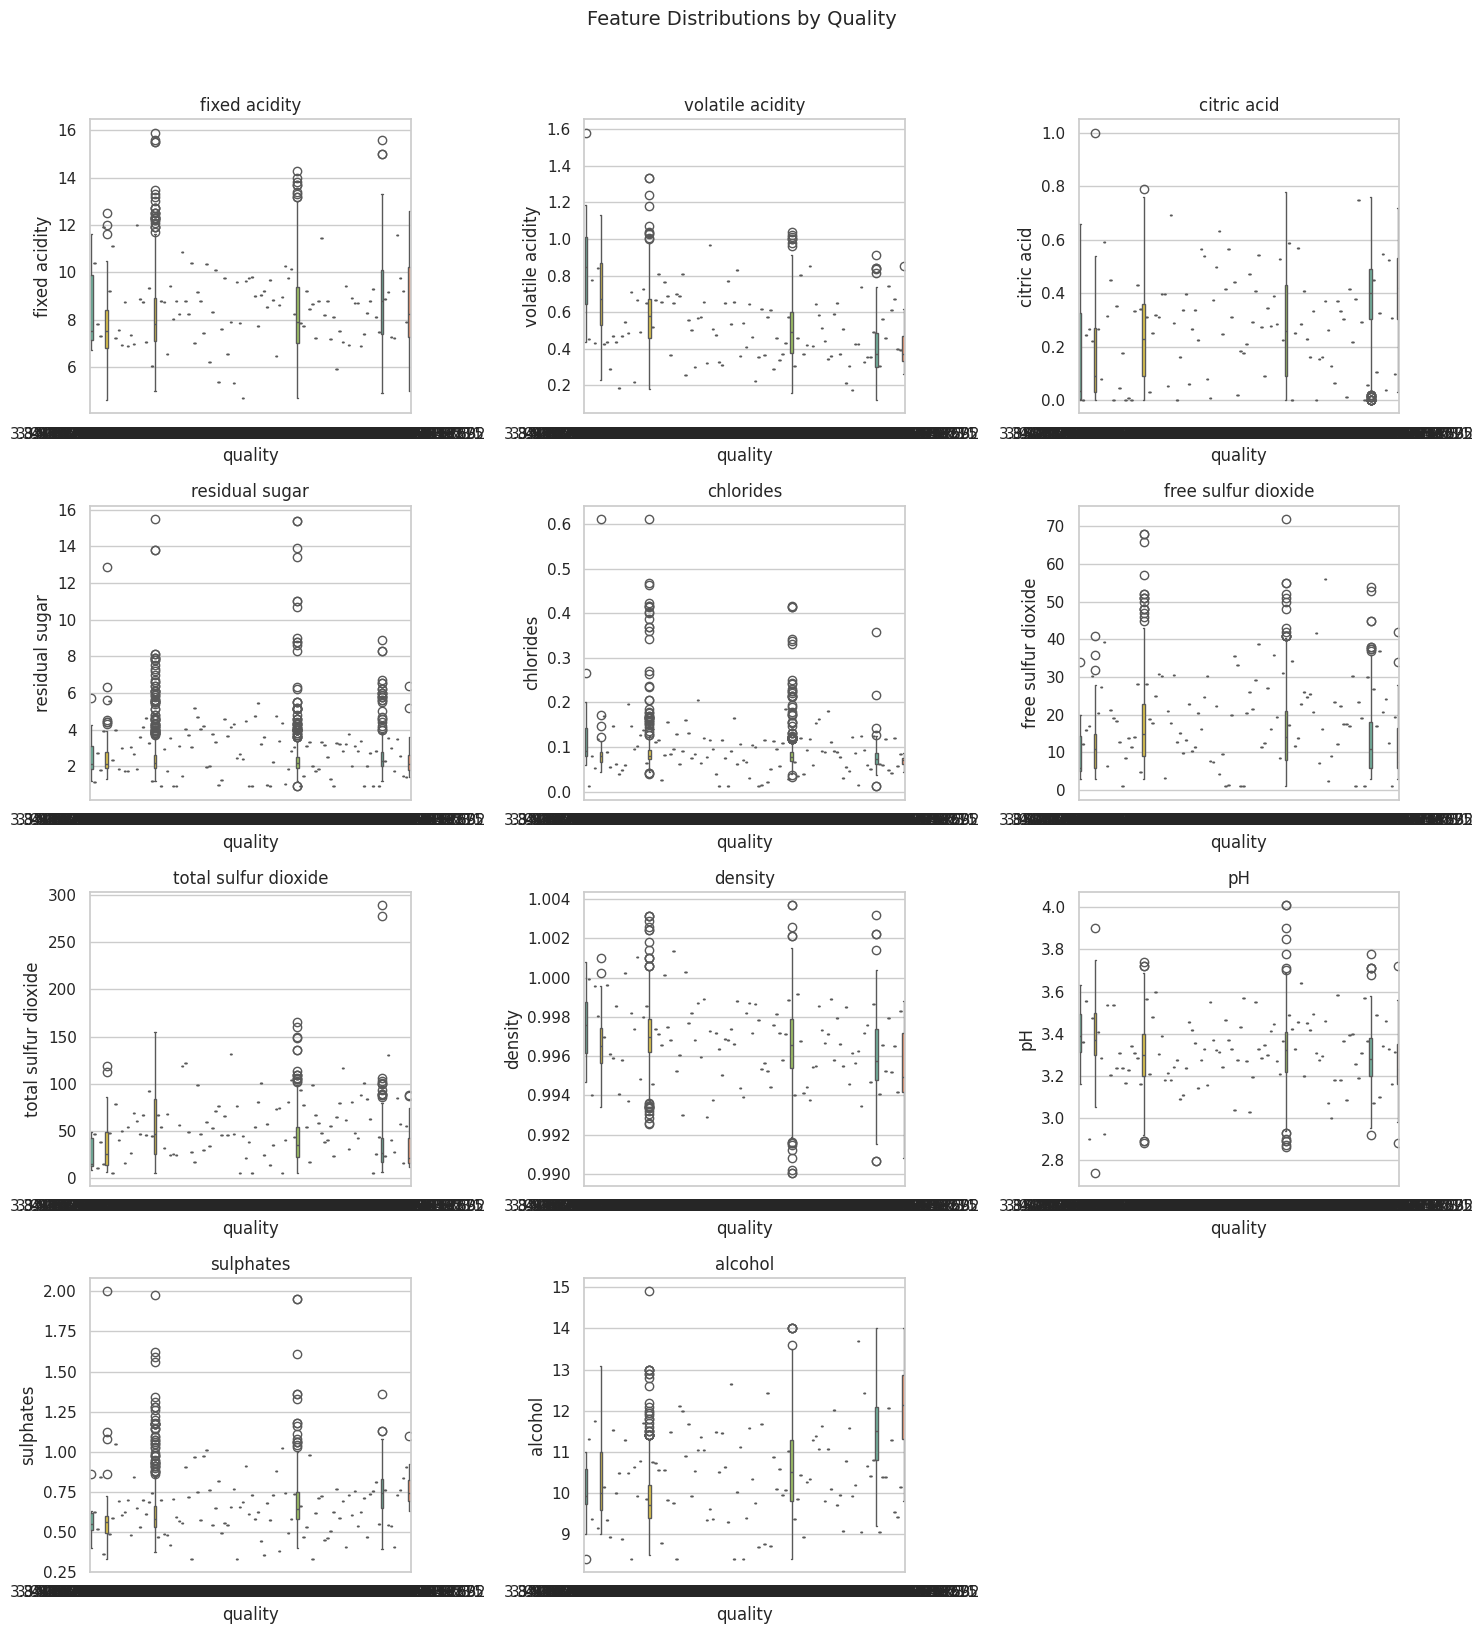

In [7]:
plot_feature_distributions(X, y)
plt.show()

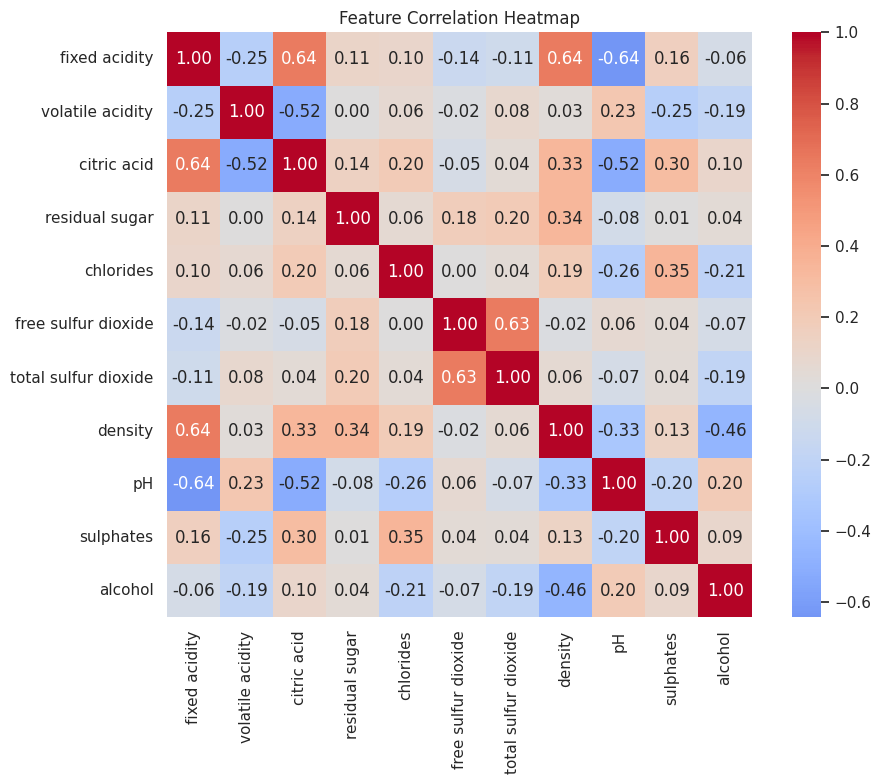

In [8]:
plot_correlation_heatmap(X)
plt.show()

## 4. Data Preprocessing

SVMs require features on the same scale. We apply `StandardScaler` (zero mean, unit variance) after splitting to prevent data leakage.

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y.round(), random_state=RANDOM_STATE
)

X_train_sc, X_test_sc, scaler = scale_features(X_train, X_test)

print(f"Training set : {X_train_sc.shape[0]} samples")
print(f"Test set     : {X_test_sc.shape[0]} samples")
print(f"\nScaled feature means (should be ~0):\n{X_train_sc.mean(axis=0).round(2)}")
print(f"\nScaled feature stds  (should be ~1):\n{X_train_sc.std(axis=0).round(2)}")

Training set : 1359 samples
Test set     : 340 samples

Scaled feature means (should be ~0):
[-0.  0. -0.  0. -0. -0. -0.  0. -0. -0. -0.]

Scaled feature stds  (should be ~1):
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


## 5. Binary Classification Setup

The quality scores range from ~3 to 8. For a cleaner binary SVM demonstration we group them into **Good** (quality >= 7) and **Not Good** (quality < 7).

In [11]:
y_bin_train = binarize_target(y_train, threshold=7)
y_bin_test = binarize_target(y_test, threshold=7)

print(f"Binary training distribution:\n{y_bin_train.value_counts().rename({0: 'Not Good', 1: 'Good'})}")
print(f"\nBinary test distribution:\n{y_bin_test.value_counts().rename({0: 'Not Good', 1: 'Good'})}")

Binary training distribution:
quality
Not Good    1176
Good         183
Name: count, dtype: int64

Binary test distribution:
quality
Not Good    298
Good         42
Name: count, dtype: int64


## 6. SVM with Linear Kernel

In [12]:
linear_svm = train_svm(X_train_sc, y_bin_train, kernel="linear",
                       random_state=RANDOM_STATE)
linear_results = evaluate_model(linear_svm, X_test_sc, y_bin_test)

print(f"Linear SVM — Test Accuracy: {linear_results['accuracy']:.4f}")
print(f"Support vectors: {linear_svm.n_support_}")
print(f"\n{linear_results['report']}")

Linear SVM — Test Accuracy: 0.8765
Support vectors: [236 183]

              precision    recall  f1-score   support

           0       0.88      1.00      0.93       298
           1       0.00      0.00      0.00        42

    accuracy                           0.88       340
   macro avg       0.44      0.50      0.47       340
weighted avg       0.77      0.88      0.82       340



## 7. SVM with RBF Kernel

In [13]:
rbf_svm = train_svm(X_train_sc, y_bin_train, kernel="rbf",
                    random_state=RANDOM_STATE)
rbf_results = evaluate_model(rbf_svm, X_test_sc, y_bin_test)

print(f"RBF SVM — Test Accuracy: {rbf_results['accuracy']:.4f}")
print(f"Support vectors: {rbf_svm.n_support_}")
print(f"\n{rbf_results['report']}")

RBF SVM — Test Accuracy: 0.9059
Support vectors: [254 179]

              precision    recall  f1-score   support

           0       0.91      0.99      0.95       298
           1       0.86      0.29      0.43        42

    accuracy                           0.91       340
   macro avg       0.88      0.64      0.69       340
weighted avg       0.90      0.91      0.88       340



## 8. SVM with Polynomial Kernel

In [14]:
poly_svm = train_svm(X_train_sc, y_bin_train, kernel="poly", degree=3,
                     random_state=RANDOM_STATE)
poly_results = evaluate_model(poly_svm, X_test_sc, y_bin_test)

print(f"Polynomial SVM — Test Accuracy: {poly_results['accuracy']:.4f}")
print(f"Support vectors: {poly_svm.n_support_}")
print(f"\n{poly_results['report']}")

Polynomial SVM — Test Accuracy: 0.8941
Support vectors: [221 174]

              precision    recall  f1-score   support

           0       0.90      0.99      0.94       298
           1       0.71      0.24      0.36        42

    accuracy                           0.89       340
   macro avg       0.81      0.61      0.65       340
weighted avg       0.88      0.89      0.87       340



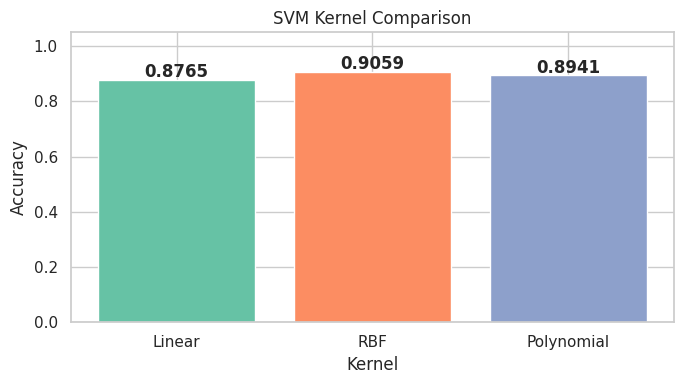

,Kernel,Accuracy,Support Vectors
0,Linear,0.876471,419
1,RBF,0.905882,433
2,Polynomial,0.894118,395


In [15]:
kernel_accuracies = {
    "Linear": linear_results["accuracy"],
    "RBF": rbf_results["accuracy"],
    "Polynomial": poly_results["accuracy"],
}
plot_kernel_comparison(kernel_accuracies)
plt.show()

comparison = pd.DataFrame({
    "Kernel": kernel_accuracies.keys(),
    "Accuracy": kernel_accuracies.values(),
    "Support Vectors": [
        sum(linear_svm.n_support_),
        sum(rbf_svm.n_support_),
        sum(poly_svm.n_support_),
    ],
})
comparison

## 9. Decision Boundary Visualization

To visualise the decision boundaries in 2-D we project the scaled features down to 2 principal components using PCA, then retrain each kernel on these 2 components.

In [16]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_train_2d = pca.fit_transform(X_train_sc)
X_test_2d = pca.transform(X_test_sc)

print(f"Explained variance ratio: {pca.explained_variance_ratio_}")
print(f"Total explained: {pca.explained_variance_ratio_.sum():.2%}")

Explained variance ratio: [0.27494615 0.17003244]
Total explained: 44.50%


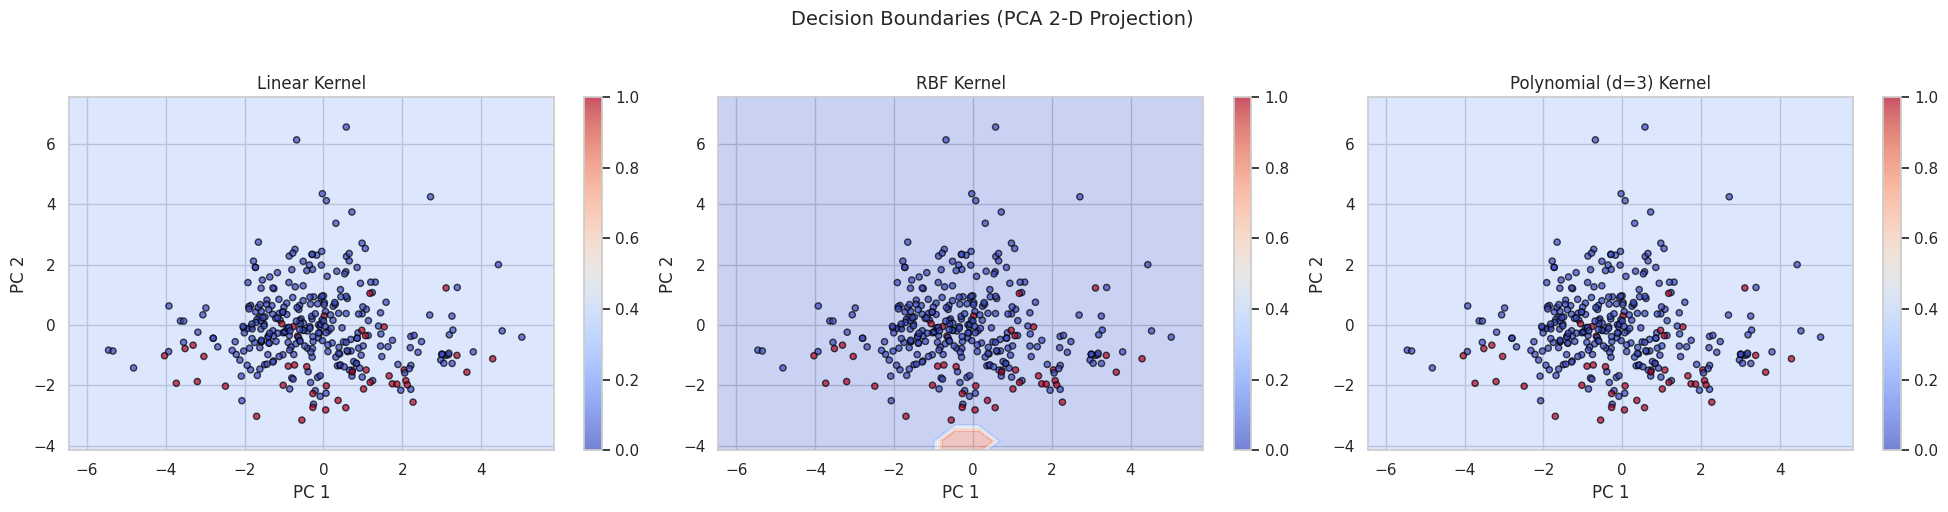

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

for ax, (name, kernel, extra_kw) in zip(axes, [
    ("Linear", "linear", {}),
    ("RBF", "rbf", {}),
    ("Polynomial (d=3)", "poly", {"degree": 3}),
]):
    svm_2d = train_svm(X_train_2d, y_bin_train, kernel=kernel,
                       random_state=RANDOM_STATE, **extra_kw)
    plot_decision_boundary(svm_2d, X_test_2d, y_bin_test.values,
                           title=f"{name} Kernel", ax=ax)

plt.suptitle("Decision Boundaries (PCA 2-D Projection)", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 10. Hyperparameter Tuning with GridSearchCV

We search over `C`, `gamma`, and `kernel` using 5-fold cross-validation on the **binary** classification task.

In [18]:
param_grid = {
    "kernel": ["linear", "rbf", "poly"],
    "C": [0.1, 1, 10, 100],
    "gamma": ["scale", "auto"],
}

search = tune_hyperparameters(X_train_sc, y_bin_train,
                              param_grid=param_grid, cv=5)

print(f"Best parameters : {search.best_params_}")
print(f"Best CV accuracy: {search.best_score_:.4f}")

Best parameters : {'C': 100, 'gamma': 'auto', 'kernel': 'rbf'}
Best CV accuracy: 0.8911


In [ ]:
cv_results = pd.DataFrame(search.cv_results_)
top_10 = cv_results.nsmallest(10, "rank_test_score")[
    ["params", "mean_test_score", "std_test_score", "mean_train_score", "rank_test_score"]
]
top_10

## 11. Multi-class Classification

Now we use the **original quality scores** (not binary) as the target. This is a harder problem with more classes and class imbalance.

In [ ]:
y_train_rounded = y_train.round().astype(int)
y_test_rounded = y_test.round().astype(int)

multi_svm = train_svm(X_train_sc, y_train_rounded, kernel="rbf", C=10,
                      gamma="scale", random_state=RANDOM_STATE)
multi_results = evaluate_model(multi_svm, X_test_sc, y_test_rounded)

print(f"Multi-class SVM (RBF, C=10) — Test Accuracy: {multi_results['accuracy']:.4f}")
print(f"\n{multi_results['report']}")

In [ ]:
class_names = sorted(y_test_rounded.unique().astype(str))
plot_confusion_matrix(multi_results["confusion_matrix"], class_names=class_names)
plt.title("Multi-class Confusion Matrix")
plt.show()

## 12. Final Evaluation — Best Binary Model

Evaluate the best model from GridSearchCV on the held-out test set.

In [ ]:
best_model = search.best_estimator_
best_results = evaluate_model(best_model, X_test_sc, y_bin_test)

print(f"Best Binary SVM — Test Accuracy: {best_results['accuracy']:.4f}")
print(f"Kernel: {best_model.kernel}, C: {best_model.C}, gamma: {best_model.gamma}")
print(f"Support vectors per class: {best_model.n_support_}")
print(f"\nClassification Report:\n{best_results['report']}")

In [ ]:
plot_confusion_matrix(best_results["confusion_matrix"],
                      class_names=["Not Good", "Good"])
plt.title("Best Binary Model — Confusion Matrix")
plt.show()

## 13. Conclusion

**Key Takeaways**

1. **Feature scaling is critical** — without `StandardScaler`, SVM performance degrades dramatically because the kernel distances are dominated by features with larger ranges.

2. **Kernel choice matters** — The RBF kernel generally performed best on this dataset, capturing non-linear relationships between the physicochemical properties and wine quality.

3. **The C parameter** controls regularisation. A larger C penalises misclassifications more (tighter fit, risk of overfitting); a smaller C allows more margin violations (simpler boundary, risk of underfitting).

4. **Binary vs Multi-class** — Binarising the target (good vs not-good) yielded higher accuracy because SVM handles two well-separated classes more naturally. Multi-class requires one-vs-one strategies and struggles with class imbalance in the original scores.

5. **Decision boundary visualisation** — Projecting to 2-D via PCA provides an intuitive view of how each kernel shapes the decision surface, even though information is lost in the projection.

**Next Steps**
- Handle class imbalance with SMOTE or class-weighted SVM (`class_weight="balanced"`)
- Try other dimensionality reduction methods (t-SNE, UMAP) for visualisation
- Compare SVM to ensemble methods (Random Forest, Gradient Boosting)
- Use `SVC(probability=True)` to obtain calibrated probabilities and plot ROC curves